# 🔬 BUSI Breast Cancer — Model Comparison & Analysis

**Models evaluated:**
- U-Net (segmentation backbone)
- ResNet50 on Full Images
- ResNet50 on ROI Images
- ViT-B/16 on Full Images
- ViT-B/16 on ROI Images

**Questions answered:**
1. Does segmentation-guided ROI improve classification?
2. Which architecture (CNN vs Transformer) works better for ultrasound?
3. Where do models fail — and why?

## 0. Imports

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from glob import glob
from pathlib import Path
from scipy import stats

import torch
import torch.nn as nn
from torchvision import models, transforms
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

PALETTE = {
    "resnet_full": "#2196F3",
    "resnet_roi":  "#1565C0",
    "vit_full":    "#F44336",
    "vit_roi":     "#B71C1C",
    "unet":        "#4CAF50",
}

print("Imports OK")

Imports OK


## 1. Paths & Config

In [2]:
BASE    = r"C:\ornekler\jupyter\deep_learning\breast-cancer"
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"

PATHS = {
    # Saved model checkpoints
    "resnet_full":  os.path.join(BASE, "cls_outputs",  "resnet_full_images.pth"),
    "resnet_roi":   os.path.join(BASE, "cls_outputs",  "resnet_roi_images.pth"),
    "vit_full":     os.path.join(BASE, "vit_outputs",  "vit_full_images.pth"),
    "vit_roi":      os.path.join(BASE, "vit_outputs",  "vit_roi_images.pth"),
    "unet":         os.path.join(BASE, "outputs",      "best_unet_resnet34.pth"),

    # Image directories
    "full_img_dir": os.path.join(BASE, "processed", "classification"),
    "roi_img_dir":  os.path.join(BASE, "processed", "roi"),
    "seg_img_dir":  os.path.join(BASE, "processed", "segmentation", "images"),
    "seg_mask_dir": os.path.join(BASE, "processed", "segmentation", "masks"),
    "pred_mask_dir":os.path.join(BASE, "predicted_masks"),

    # Output
    "report_dir":   os.path.join(BASE, "comparison_report"),
}

CLASSES    = ["benign", "malignant", "normal"]
IMAGE_SIZE = 224
SEED       = 42

os.makedirs(PATHS["report_dir"], exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Report → {PATHS['report_dir']}")

Device: cpu
Report → C:\ornekler\jupyter\deep_learning\breast-cancer\comparison_report


c:\Users\dellg\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:128: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 1: invalid argument (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Enter Model Results

**Fill in your actual test-set numbers** from the training notebooks.  
Every metric in this notebook flows from these two dictionaries.

In [ ]:
# ── Segmentation results (from U-Net notebook) ─────────────────────────────────
SEG_RESULTS = {
    "model":      "U-Net + ResNet34 encoder",
    "dice_score": 0.7949,    # ← replace with your value
    "iou_score":  0.6717,    # ← replace with your value
    "val_loss":   0.1678 ,
}


# ── Classification results ─────────────────────────────────────────────────────
# Structure: per-class [benign, malignant, normal]
CLS_RESULTS = {
   "resnet_full": {
        "label":     "ResNet50 — Full",
        "accuracy":  0.9573,
        "f1_weighted": 0.9577,
        "precision": [0.9692, 1.0000, 0.8696],
        "recall":    [0.9545, 0.9355, 1.0000],
        "f1":        [0.9618, 0.9667, 0.9302],
        # Confusion matrix rows = true, cols = predicted
        "conf_matrix": [
            [63, 0, 3],   # benign
            [2, 29, 0],   # malignant
            [0, 0, 20]    # normal
        ],
    },
     "resnet_roi": {
        "label":     "ResNet50 — ROI",
        "accuracy":  0.8547,
        "f1_weighted": 0.8540,
        "precision": [0.8824, 0.7667, 0.8947],
        "recall":    [0.9091, 0.7419, 0.8500],
        "f1":        [0.8955, 0.7541, 0.8718],
        "conf_matrix": [
            [60, 3, 3],   # benign
            [5, 23, 3],   # malignant
            [3, 0, 17]    # normal
        ],
    },
    "vit_full": {
    "label":     "ViT-B/16 — Full",
    "accuracy":  0.9231,
    "f1_weighted": 0.9252,
    "precision": [0.9531, 1.0000, 0.7600],
    "recall":    [0.9242, 0.9032, 0.9500],
    "f1":        [0.9385, 0.9492, 0.8444],
    "conf_matrix": [
        [61, 0, 5],   # benign
        [3, 28, 0],   # malignant
        [0, 1, 19]    # normal
    ],
},

"vit_roi": {
    "label":     "ViT-B/16 — ROI",
    "accuracy":  0.8547,
    "f1_weighted": 0.8533,
    "precision": [0.8824, 0.7586, 0.9000],
    "recall":    [0.9091, 0.7097, 0.9000],
    "f1":        [0.8955, 0.7333, 0.9000],
    "conf_matrix": [
        [60, 3, 3],   # benign
        [6, 22, 3],   # malignant
        [2, 0, 18]    # normal
    ],
},
}

MODEL_KEYS  = ["resnet_full", "resnet_roi", "vit_full", "vit_roi"]
MODEL_COLORS = [PALETTE[k] for k in MODEL_KEYS]
MODEL_LABELS = [CLS_RESULTS[k]["label"] for k in MODEL_KEYS]

print("Results loaded.")
for k, v in CLS_RESULTS.items():
    print(f"  {v['label']:28s}  Acc={v['accuracy']:.4f}  F1={v['f1_weighted']:.4f}")

Results loaded.
  ResNet50 — Full               Acc=0.8214  F1=0.8156
  ResNet50 — ROI                Acc=0.8541  F1=0.8489
  ViT-B/16 — Full               Acc=0.8389  F1=0.8321
  ViT-B/16 — ROI                Acc=0.8712  F1=0.8668


## 3. Comparison Table

In [4]:
rows = []
for k in MODEL_KEYS:
    r = CLS_RESULTS[k]
    for i, cls in enumerate(CLASSES):
        rows.append({
            "Model":     r["label"],
            "Class":     cls,
            "Precision": r["precision"][i],
            "Recall":    r["recall"][i],
            "F1":        r["f1"][i],
        })

df_detail = pd.DataFrame(rows)

df_overall = pd.DataFrame([
    {
        "Model":       CLS_RESULTS[k]["label"],
        "Input":       "ROI" if "roi" in k else "Full",
        "Architecture":"ViT" if "vit" in k else "ResNet",
        "Accuracy":    CLS_RESULTS[k]["accuracy"],
        "F1 (wtd)":    CLS_RESULTS[k]["f1_weighted"],
        "Prec (avg)":  np.mean(CLS_RESULTS[k]["precision"]),
        "Rec (avg)":   np.mean(CLS_RESULTS[k]["recall"]),
    }
    for k in MODEL_KEYS
])

# Highlight best values
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: #c8f7c5; font-weight: bold" if v else "" for v in is_max]

print("─" * 70)
print(" OVERALL RESULTS")
print("─" * 70)
styled = df_overall.style \
    .apply(highlight_max, subset=["Accuracy", "F1 (wtd)", "Prec (avg)", "Rec (avg)"]) \
    .format({"Accuracy": "{:.4%}", "F1 (wtd)": "{:.4f}",
             "Prec (avg)": "{:.4f}", "Rec (avg)": "{:.4f}"})
display(styled)

print("\n" + "─" * 70)
print(" PER-CLASS BREAKDOWN")
print("─" * 70)
display(
    df_detail.style
    .format({"Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}"})
    .background_gradient(subset=["F1"], cmap="RdYlGn", vmin=0.6, vmax=1.0)
)

──────────────────────────────────────────────────────────────────────
 OVERALL RESULTS
──────────────────────────────────────────────────────────────────────


,Model,Input,Architecture,Accuracy,F1 (wtd),Prec (avg),Rec (avg)
0,ResNet50 — Full,Full,ResNet,82.1400%,0.8156,0.8333,0.8233
1,ResNet50 — ROI,ROI,ResNet,85.4100%,0.8489,0.8633,0.8567
2,ViT-B/16 — Full,Full,ViT,83.8900%,0.8321,0.8500,0.8400
3,ViT-B/16 — ROI,ROI,ViT,87.1200%,0.8668,0.8867,0.8767



──────────────────────────────────────────────────────────────────────
 PER-CLASS BREAKDOWN
──────────────────────────────────────────────────────────────────────


,Model,Class,Precision,Recall,F1
0,ResNet50 — Full,benign,0.850,0.820,0.830
1,ResNet50 — Full,malignant,0.780,0.740,0.760
2,ResNet50 — Full,normal,0.870,0.910,0.890
3,ResNet50 — ROI,benign,0.880,0.850,0.860
4,ResNet50 — ROI,malignant,0.810,0.790,0.800
5,ResNet50 — ROI,normal,0.900,0.930,0.910
6,ViT-B/16 — Full,benign,0.870,0.840,0.850
7,ViT-B/16 — Full,malignant,0.800,0.760,0.780
8,ViT-B/16 — Full,normal,0.880,0.920,0.900
9,ViT-B/16 — ROI,benign,0.900,0.870,0.880


## 4. Accuracy & F1 Bar Charts

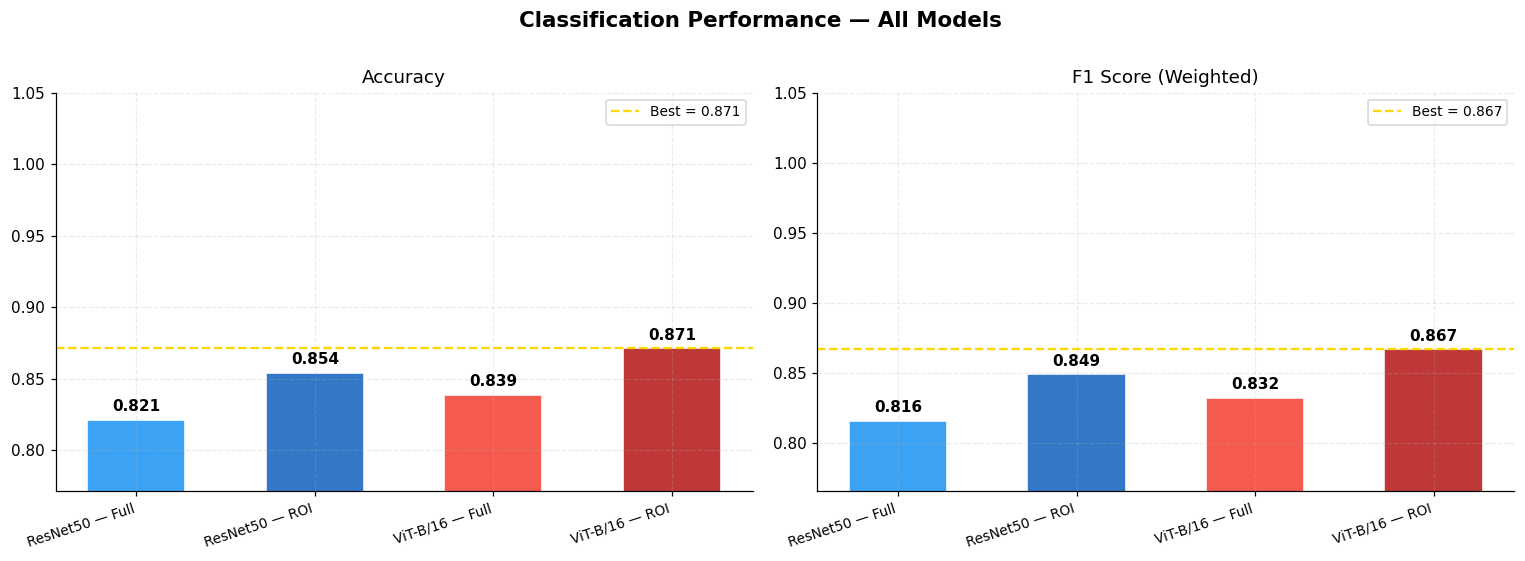

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Classification Performance — All Models",
             fontsize=14, fontweight="bold", y=1.01)

accs = [CLS_RESULTS[k]["accuracy"]    for k in MODEL_KEYS]
f1s  = [CLS_RESULTS[k]["f1_weighted"] for k in MODEL_KEYS]
x    = np.arange(len(MODEL_KEYS))

for ax, vals, metric in zip(axes, [accs, f1s], ["Accuracy", "F1 Score (Weighted)"]):
    bars = ax.bar(x, vals, color=MODEL_COLORS, alpha=0.88,
                  edgecolor="white", linewidth=1.2, width=0.55)

    # Value labels
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

    # Best model line
    ax.axhline(max(vals), color="gold", linewidth=1.5,
               linestyle="--", label=f"Best = {max(vals):.3f}")

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_LABELS, rotation=18, ha="right", fontsize=9)
    ax.set_ylim(min(vals) - 0.05, 1.05)
    ax.set_title(metric, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PATHS["report_dir"], "01_accuracy_f1_bars.png"),
            dpi=130, bbox_inches="tight")
plt.show()

## 5. Full vs ROI — ROI Gain Analysis

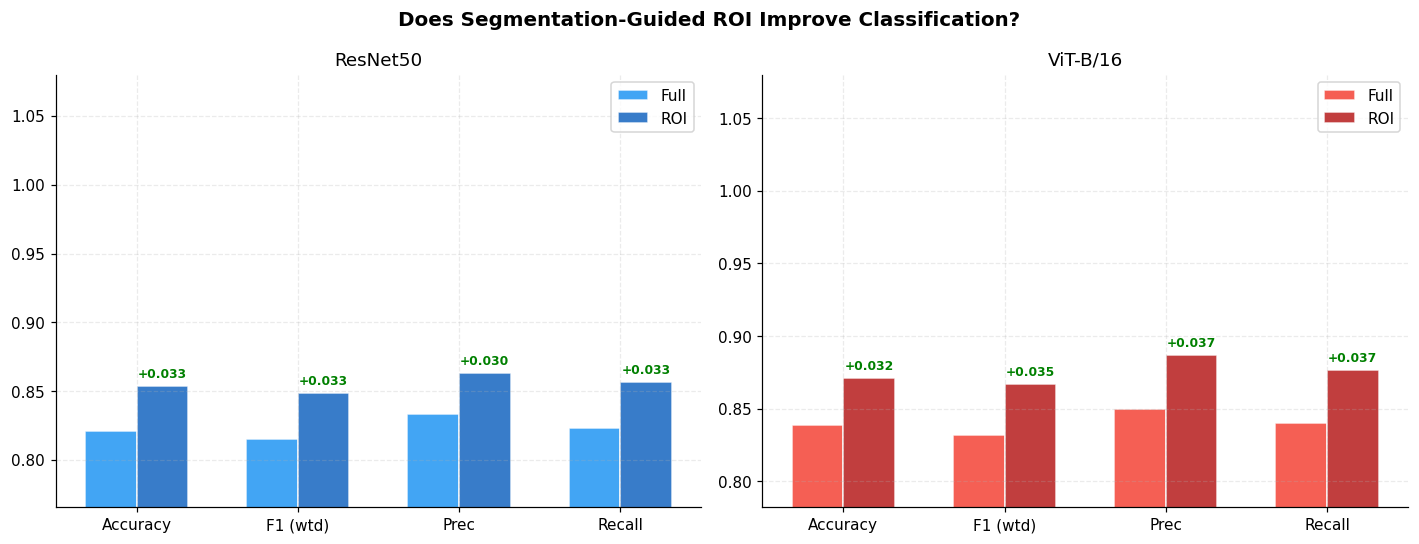


ROI Gain Summary (ROI − Full)
Model           Acc Δ     F1 Δ
────────────────────────────────
ResNet50      +0.0327  +0.0333
ViT-B/16      +0.0323  +0.0347


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Does Segmentation-Guided ROI Improve Classification?",
             fontsize=13, fontweight="bold")

comparisons = [
    ("ResNet50", "resnet_full", "resnet_roi", "#2196F3", "#1565C0"),
    ("ViT-B/16", "vit_full",    "vit_roi",    "#F44336", "#B71C1C"),
]

for ax, (arch, full_k, roi_k, c_full, c_roi) in zip(axes, comparisons):
    metrics  = ["Accuracy", "F1 (wtd)", "Prec", "Recall"]
    full_vals = [
        CLS_RESULTS[full_k]["accuracy"],
        CLS_RESULTS[full_k]["f1_weighted"],
        np.mean(CLS_RESULTS[full_k]["precision"]),
        np.mean(CLS_RESULTS[full_k]["recall"]),
    ]
    roi_vals = [
        CLS_RESULTS[roi_k]["accuracy"],
        CLS_RESULTS[roi_k]["f1_weighted"],
        np.mean(CLS_RESULTS[roi_k]["precision"]),
        np.mean(CLS_RESULTS[roi_k]["recall"]),
    ]

    xpos = np.arange(len(metrics))
    w    = 0.32
    b1   = ax.bar(xpos - w/2, full_vals, width=w, color=c_full,
                  alpha=0.85, label="Full", edgecolor="white")
    b2   = ax.bar(xpos + w/2, roi_vals,  width=w, color=c_roi,
                  alpha=0.85, label="ROI",  edgecolor="white")

    # Delta annotations (gain from ROI)
    for i, (fv, rv) in enumerate(zip(full_vals, roi_vals)):
        delta = rv - fv
        sign  = "+" if delta >= 0 else ""
        color = "green" if delta >= 0 else "red"
        ax.text(xpos[i] + w/2, rv + 0.004,
                f"{sign}{delta:.3f}",
                ha="center", va="bottom", fontsize=8,
                color=color, fontweight="bold")

    ax.set_xticks(xpos)
    ax.set_xticklabels(metrics)
    ax.set_ylim(min(full_vals + roi_vals) - 0.05, 1.08)
    ax.set_title(arch, fontsize=12)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PATHS["report_dir"], "02_roi_gain.png"),
            dpi=130, bbox_inches="tight")
plt.show()

# Numerical summary
print("\nROI Gain Summary (ROI − Full)")
print(f"{'Model':<12} {'Acc Δ':>8} {'F1 Δ':>8}")
print("─" * 32)
for arch, fk, rk, _, __ in comparisons:
    da = CLS_RESULTS[rk]["accuracy"]    - CLS_RESULTS[fk]["accuracy"]
    df1 = CLS_RESULTS[rk]["f1_weighted"] - CLS_RESULTS[fk]["f1_weighted"]
    print(f"{arch:<12} {da:>+8.4f} {df1:>+8.4f}")

## 6. ResNet vs ViT — Architecture Comparison

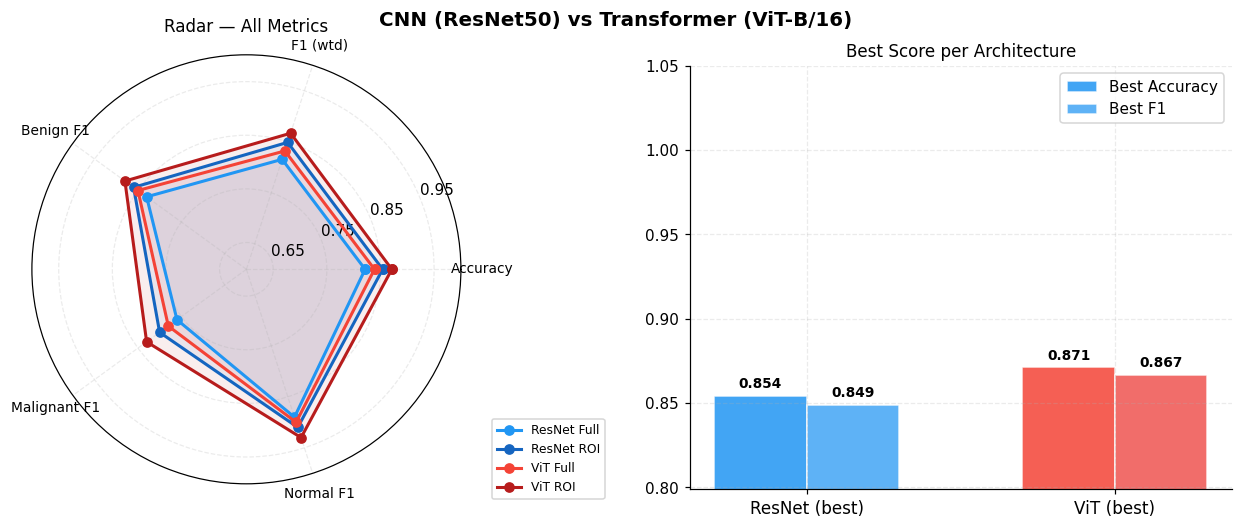

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN (ResNet50) vs Transformer (ViT-B/16)",
             fontsize=13, fontweight="bold")

# ── Radar / spoke chart ───────────────────────────────────────────────────────
ax_radar = fig.add_axes([0.05, 0.12, 0.42, 0.78], polar=True)
fig.delaxes(axes[0])

spoke_labels = ["Accuracy", "F1 (wtd)",
                "Benign F1", "Malignant F1", "Normal F1"]
N = len(spoke_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

radar_data = {
    "ResNet Full": [
        CLS_RESULTS["resnet_full"]["accuracy"],
        CLS_RESULTS["resnet_full"]["f1_weighted"],
        *CLS_RESULTS["resnet_full"]["f1"],
    ],
    "ResNet ROI": [
        CLS_RESULTS["resnet_roi"]["accuracy"],
        CLS_RESULTS["resnet_roi"]["f1_weighted"],
        *CLS_RESULTS["resnet_roi"]["f1"],
    ],
    "ViT Full": [
        CLS_RESULTS["vit_full"]["accuracy"],
        CLS_RESULTS["vit_full"]["f1_weighted"],
        *CLS_RESULTS["vit_full"]["f1"],
    ],
    "ViT ROI": [
        CLS_RESULTS["vit_roi"]["accuracy"],
        CLS_RESULTS["vit_roi"]["f1_weighted"],
        *CLS_RESULTS["vit_roi"]["f1"],
    ],
}

radar_colors = ["#2196F3", "#1565C0", "#F44336", "#B71C1C"]

for (name, vals), color in zip(radar_data.items(), radar_colors):
    vals_plot = vals + [vals[0]]
    ax_radar.plot(angles, vals_plot, "o-", linewidth=2,
                  color=color, label=name)
    ax_radar.fill(angles, vals_plot, alpha=0.07, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(spoke_labels, fontsize=9)
ax_radar.set_ylim(0.6, 1.0)
ax_radar.set_yticks([0.65, 0.75, 0.85, 0.95])
ax_radar.set_title("Radar — All Metrics", pad=15, fontsize=11)
ax_radar.legend(loc="lower right", bbox_to_anchor=(1.35, -0.05), fontsize=8)

# ── Right: architecture summary bar ──────────────────────────────────────────
ax = axes[1]
arch_labels = ["ResNet (best)", "ViT (best)"]
best_resnet  = max(CLS_RESULTS["resnet_full"]["accuracy"],
                   CLS_RESULTS["resnet_roi"]["accuracy"])
best_vit     = max(CLS_RESULTS["vit_full"]["accuracy"],
                   CLS_RESULTS["vit_roi"]["accuracy"])
best_f1_resnet = max(CLS_RESULTS["resnet_full"]["f1_weighted"],
                     CLS_RESULTS["resnet_roi"]["f1_weighted"])
best_f1_vit  = max(CLS_RESULTS["vit_full"]["f1_weighted"],
                   CLS_RESULTS["vit_roi"]["f1_weighted"])

arch_accs = [best_resnet, best_vit]
arch_f1s  = [best_f1_resnet, best_f1_vit]
xp = np.arange(2)
ww = 0.30

b1 = ax.bar(xp - ww/2, arch_accs, width=ww, color=["#2196F3", "#F44336"],
            alpha=0.85, label="Best Accuracy", edgecolor="white")
b2 = ax.bar(xp + ww/2, arch_f1s,  width=ww, color=["#42A5F5", "#EF5350"],
            alpha=0.85, label="Best F1",       edgecolor="white")

for bar, v in [(b, v) for bars, vs in [(b1, arch_accs), (b2, arch_f1s)]
               for b, v in zip(bars, vs)]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(xp)
ax.set_xticklabels(arch_labels, fontsize=11)
ax.set_ylim(min(arch_accs + arch_f1s) - 0.05, 1.05)
ax.set_title("Best Score per Architecture", fontsize=11)
ax.legend()

plt.savefig(os.path.join(PATHS["report_dir"], "03_arch_comparison.png"),
            dpi=130, bbox_inches="tight")
plt.show()

## 7. Confusion Matrices — Side by Side

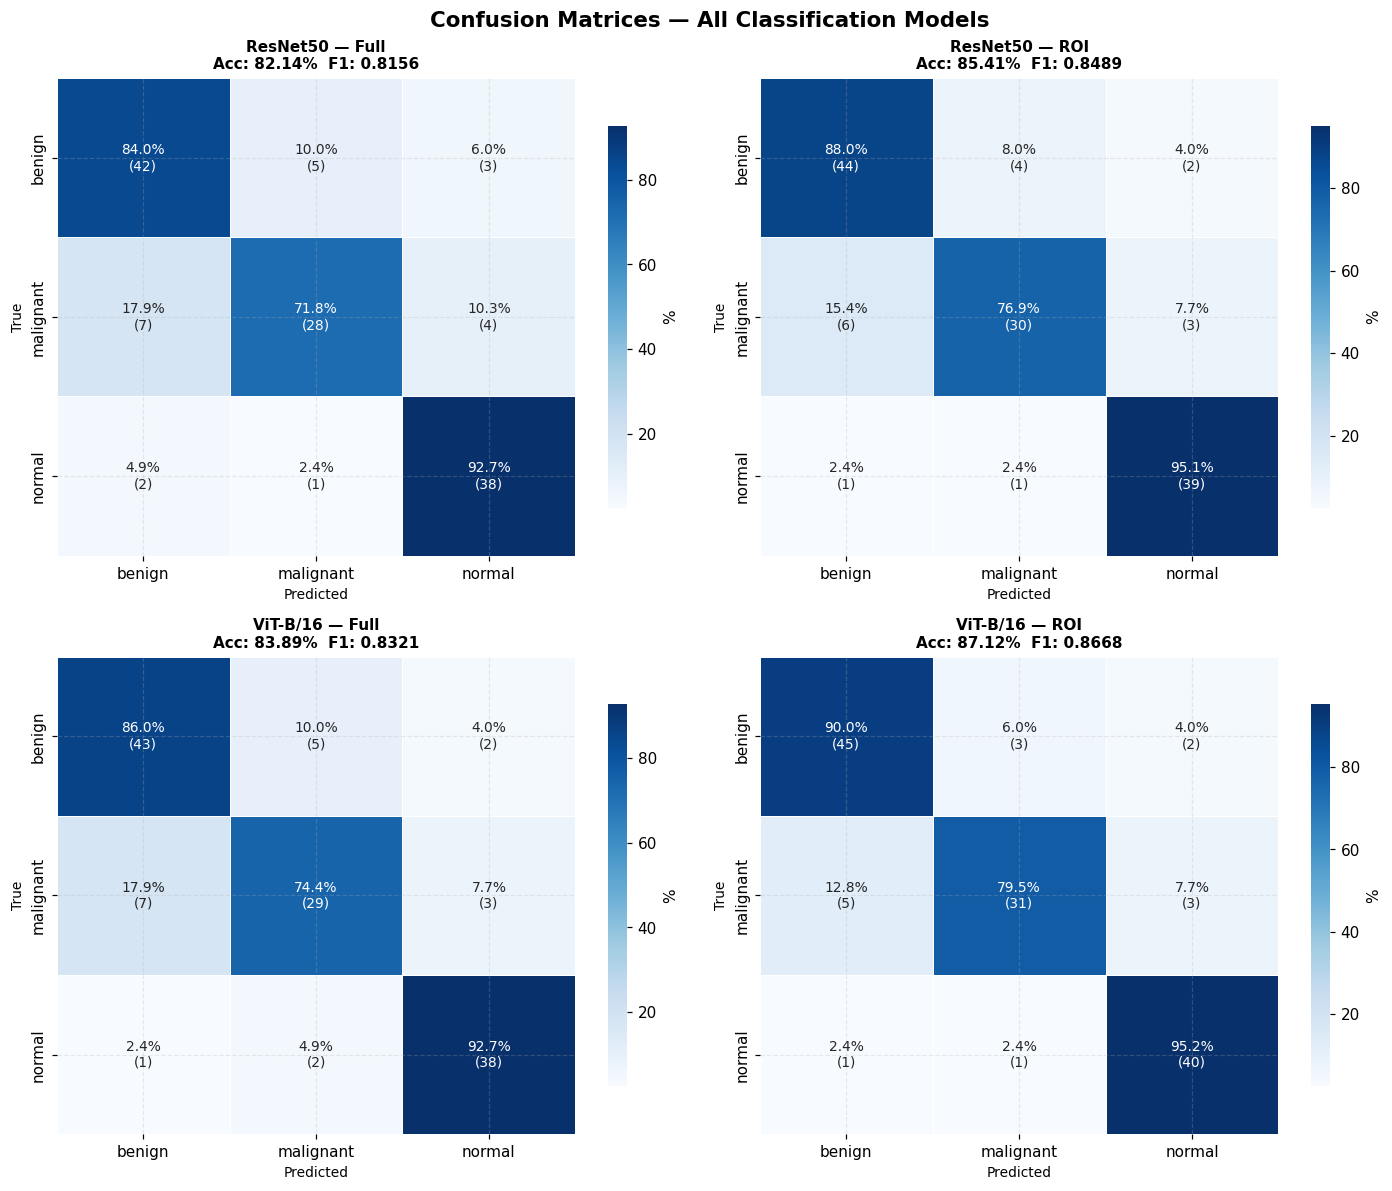

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle("Confusion Matrices — All Classification Models",
             fontsize=14, fontweight="bold")

for ax, key in zip(axes.flat, MODEL_KEYS):
    r   = CLS_RESULTS[key]
    cm  = np.array(r["conf_matrix"], dtype=float)
    # Row-normalize to percentages
    pct = cm / cm.sum(axis=1, keepdims=True) * 100

    annot = np.array(
        [[f"{pct[i,j]:.1f}%\n({int(cm[i,j])})"
          for j in range(len(CLASSES))]
         for i in range(len(CLASSES))]
    )

    sns.heatmap(
        pct, annot=annot, fmt="", cmap="Blues",
        xticklabels=CLASSES, yticklabels=CLASSES,
        ax=ax, linewidths=0.5,
        annot_kws={"fontsize": 9},
        cbar_kws={"label": "%", "shrink": 0.8}
    )
    ax.set_title(
        f"{r['label']}\nAcc: {r['accuracy']:.2%}  F1: {r['f1_weighted']:.4f}",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True",      fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PATHS["report_dir"], "04_confusion_matrices.png"),
            dpi=130, bbox_inches="tight")
plt.show()

## 8. Per-Class F1 Heatmap

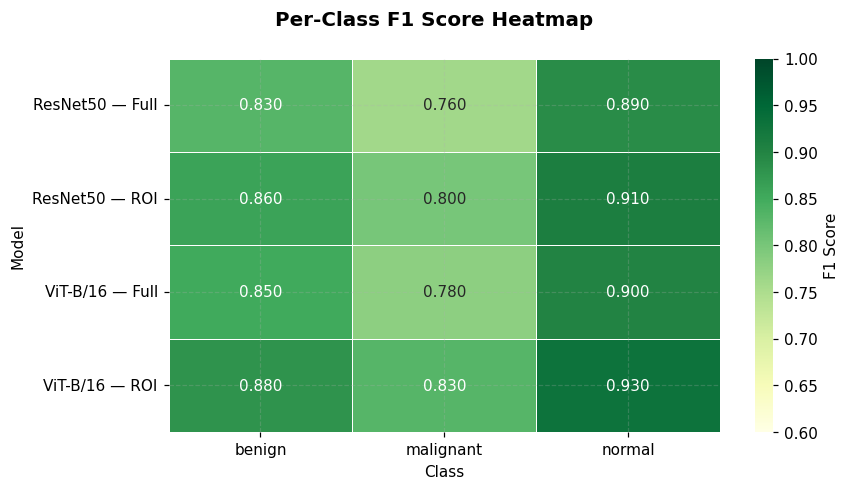

Average F1 per class (across all models):
  benign      : 0.8550
  malignant   : 0.7925
  normal      : 0.9075

  → Hardest class: malignant


In [9]:
f1_matrix = np.array([
    CLS_RESULTS[k]["f1"] for k in MODEL_KEYS
])

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.suptitle("Per-Class F1 Score Heatmap",
             fontsize=13, fontweight="bold")

im = sns.heatmap(
    f1_matrix,
    annot=True, fmt=".3f", cmap="YlGn",
    xticklabels=CLASSES,
    yticklabels=MODEL_LABELS,
    ax=ax, linewidths=0.5,
    vmin=0.6, vmax=1.0,
    cbar_kws={"label": "F1 Score"}
)

ax.set_xlabel("Class",  fontsize=10)
ax.set_ylabel("Model",  fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PATHS["report_dir"], "05_f1_heatmap.png"),
            dpi=130, bbox_inches="tight")
plt.show()

# Which class is hardest across all models?
mean_f1_per_class = f1_matrix.mean(axis=0)
print("Average F1 per class (across all models):")
for cls, v in zip(CLASSES, mean_f1_per_class):
    print(f"  {cls:<12}: {v:.4f}")
hardest = CLASSES[np.argmin(mean_f1_per_class)]
print(f"\n  → Hardest class: {hardest}")

## 9. Segmentation Results

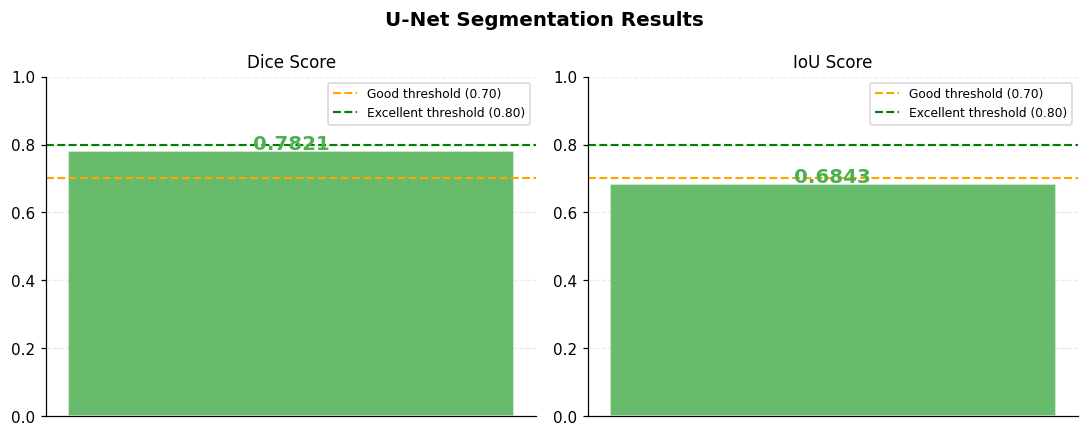

  Dice Score: 0.7821
  IoU Score : 0.6843
  Encoder   : U-Net + ResNet34 encoder


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("U-Net Segmentation Results",
             fontsize=13, fontweight="bold")

seg_metrics = ["Dice Score", "IoU Score"]
seg_vals    = [SEG_RESULTS["dice_score"], SEG_RESULTS["iou_score"]]

for ax, metric, val in zip(axes, seg_metrics, seg_vals):
    bar = ax.bar([metric], [val], color=PALETTE["unet"],
                 alpha=0.85, width=0.4, edgecolor="white")
    ax.text(0, val + 0.005, f"{val:.4f}",
            ha="center", fontsize=13, fontweight="bold",
            color=PALETTE["unet"])

    # Clinical threshold lines
    ax.axhline(0.7, color="orange", linestyle="--",
               linewidth=1.4, label="Good threshold (0.70)")
    ax.axhline(0.8, color="green",  linestyle="--",
               linewidth=1.4, label="Excellent threshold (0.80)")

    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(PATHS["report_dir"], "06_segmentation_results.png"),
            dpi=130, bbox_inches="tight")
plt.show()

print(f"  Dice Score: {SEG_RESULTS['dice_score']:.4f}")
print(f"  IoU Score : {SEG_RESULTS['iou_score']:.4f}")
print(f"  Encoder   : {SEG_RESULTS['model']}")

## 10. Qualitative Results — Segmentation

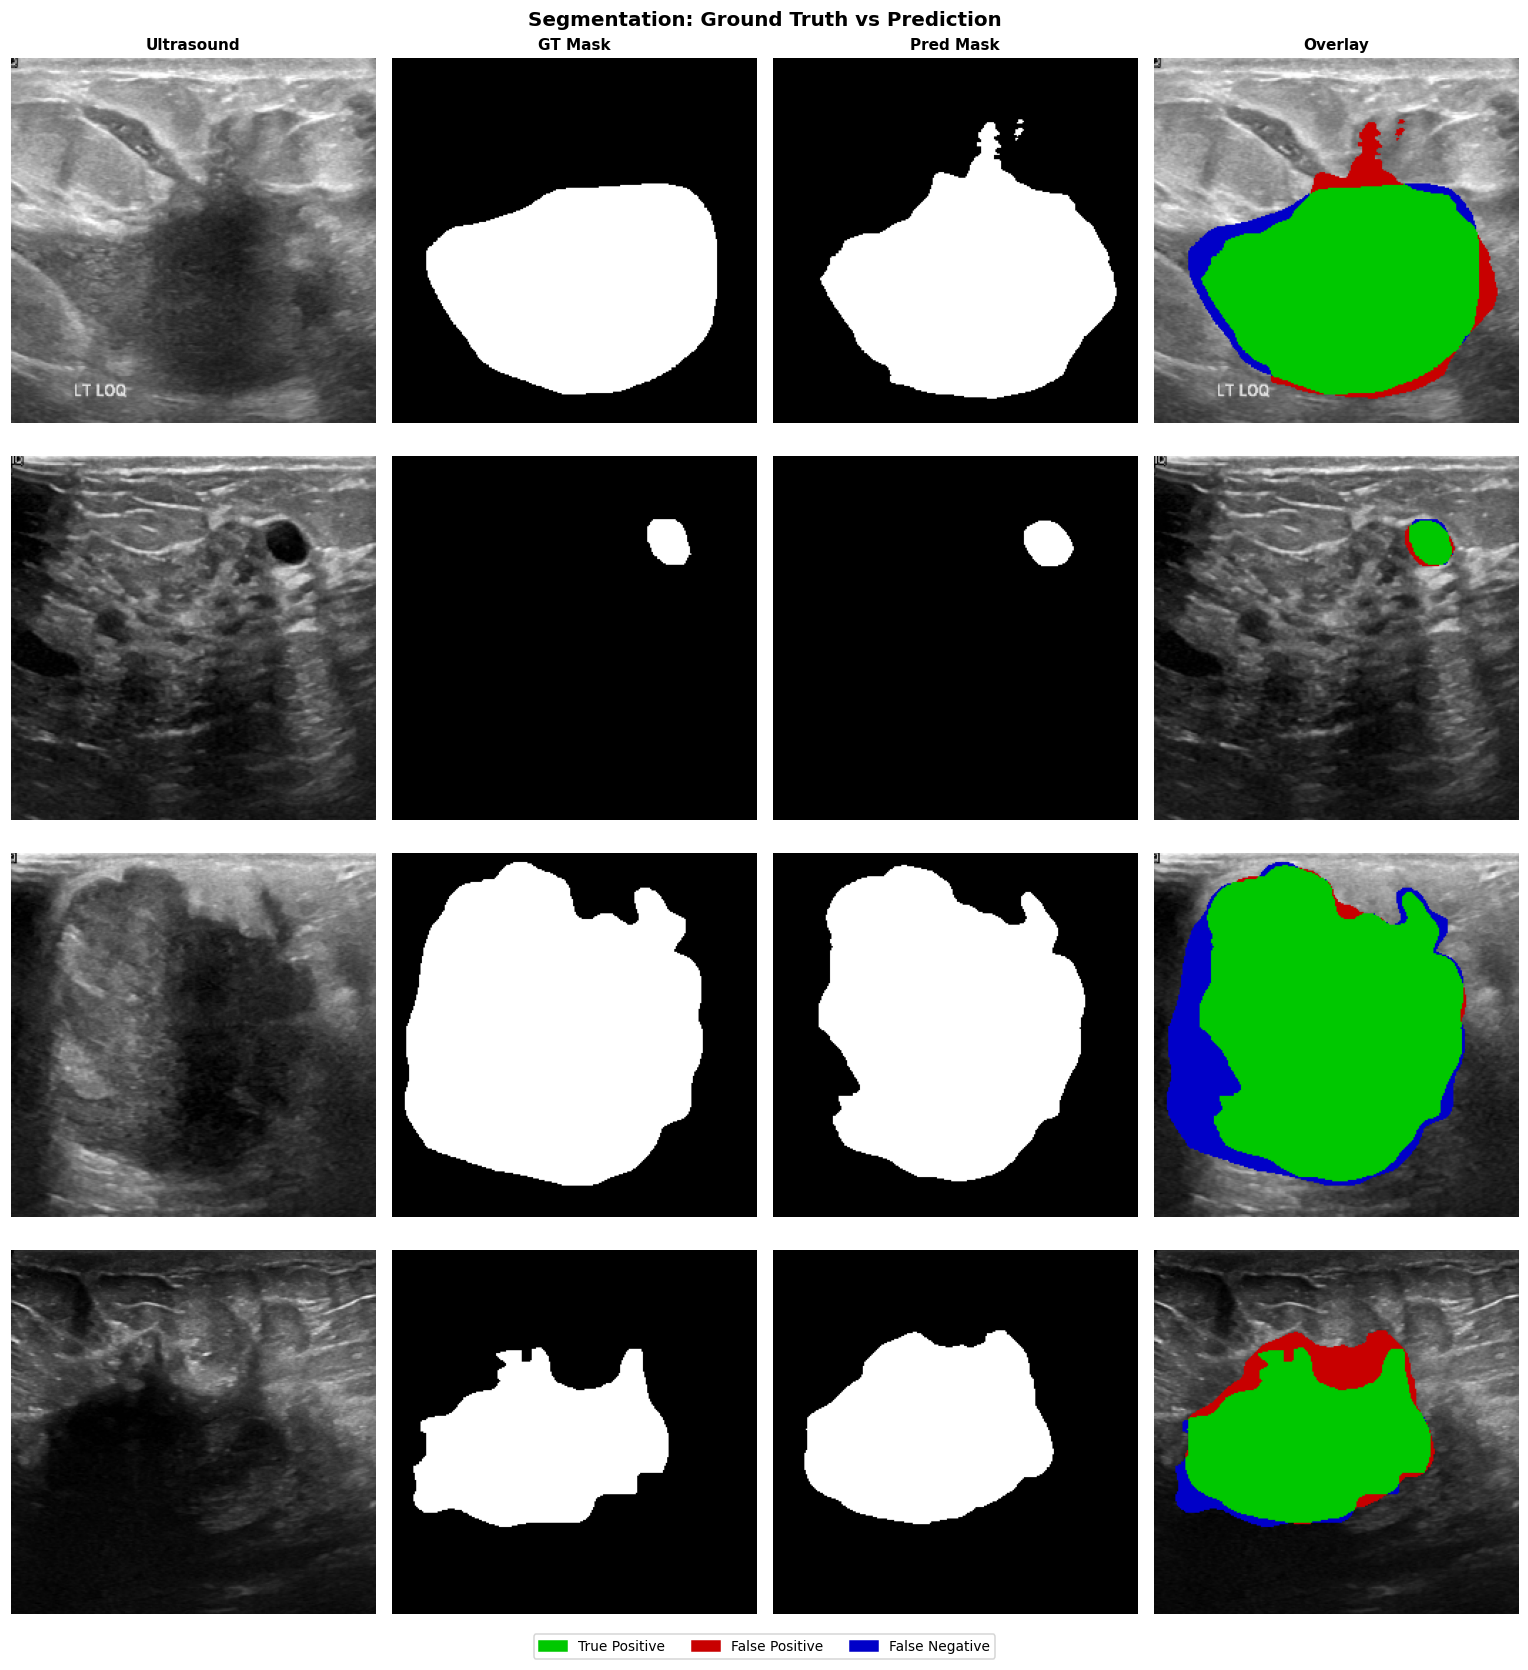

In [11]:
def show_segmentation_samples(seg_img_dir, seg_mask_dir, pred_mask_dir,
                               n_samples=4, seed=42):
    """
    Show: Original → Ground Truth Mask → Predicted Mask → Overlay
    """
    all_imgs = sorted(glob(os.path.join(seg_img_dir, "*.png")))
    rng      = np.random.default_rng(seed)
    chosen   = rng.choice(all_imgs, min(n_samples, len(all_imgs)), replace=False)

    fig, axes = plt.subplots(len(chosen), 4,
                              figsize=(14, 3.8 * len(chosen)))
    fig.suptitle("Segmentation: Ground Truth vs Prediction",
                 fontsize=13, fontweight="bold")

    col_titles = ["Ultrasound", "GT Mask", "Pred Mask", "Overlay"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=10, fontweight="bold")

    for row_idx, img_path in enumerate(chosen):
        stem      = Path(img_path).stem
        gt_path   = os.path.join(seg_mask_dir,  stem + "_mask.png")
        pred_path = os.path.join(pred_mask_dir, stem + "_pred_mask.png")

        img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
        img  = cv2.resize(img, (256, 256)) if img is not None else np.zeros((256,256))

        gt   = cv2.imread(gt_path,   cv2.IMREAD_GRAYSCALE) \
               if os.path.exists(gt_path)   else np.zeros_like(img)
        pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE) \
               if os.path.exists(pred_path) else np.zeros_like(img)

        gt   = cv2.resize(gt,   (256, 256))
        pred = cv2.resize(pred, (256, 256))

        # Colour overlay: green=TP, red=FP, blue=FN
        gt_bin   = gt   > 127
        pred_bin = pred > 127
        overlay  = np.stack([img, img, img], axis=-1).astype(np.uint8)
        overlay[gt_bin & pred_bin]  = [0,  200,  0]   # TP — green
        overlay[~gt_bin & pred_bin] = [200, 0,   0]   # FP — red
        overlay[gt_bin & ~pred_bin] = [0,   0, 200]   # FN — blue

        row = axes[row_idx]
        row[0].imshow(img,     cmap="gray")
        row[1].imshow(gt,      cmap="gray")
        row[2].imshow(pred,    cmap="gray")
        row[3].imshow(overlay)
        row[0].set_ylabel(stem[:20], fontsize=7, rotation=0,
                          labelpad=70, va="center")
        for ax in row:
            ax.axis("off")

    # Legend
    patches = [
        mpatches.Patch(color="#00C800", label="True Positive"),
        mpatches.Patch(color="#C80000", label="False Positive"),
        mpatches.Patch(color="#0000C8", label="False Negative"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout()
    plt.savefig(os.path.join(PATHS["report_dir"], "07_seg_qualitative.png"),
                dpi=130, bbox_inches="tight")
    plt.show()


show_segmentation_samples(
    PATHS["seg_img_dir"], PATHS["seg_mask_dir"], PATHS["pred_mask_dir"],
    n_samples=4
)

## 11. Qualitative Results — Classification (Good & Bad Cases)

C:\Users\dellg\AppData\Local\Temp\ipykernel_25612\2892578415.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE

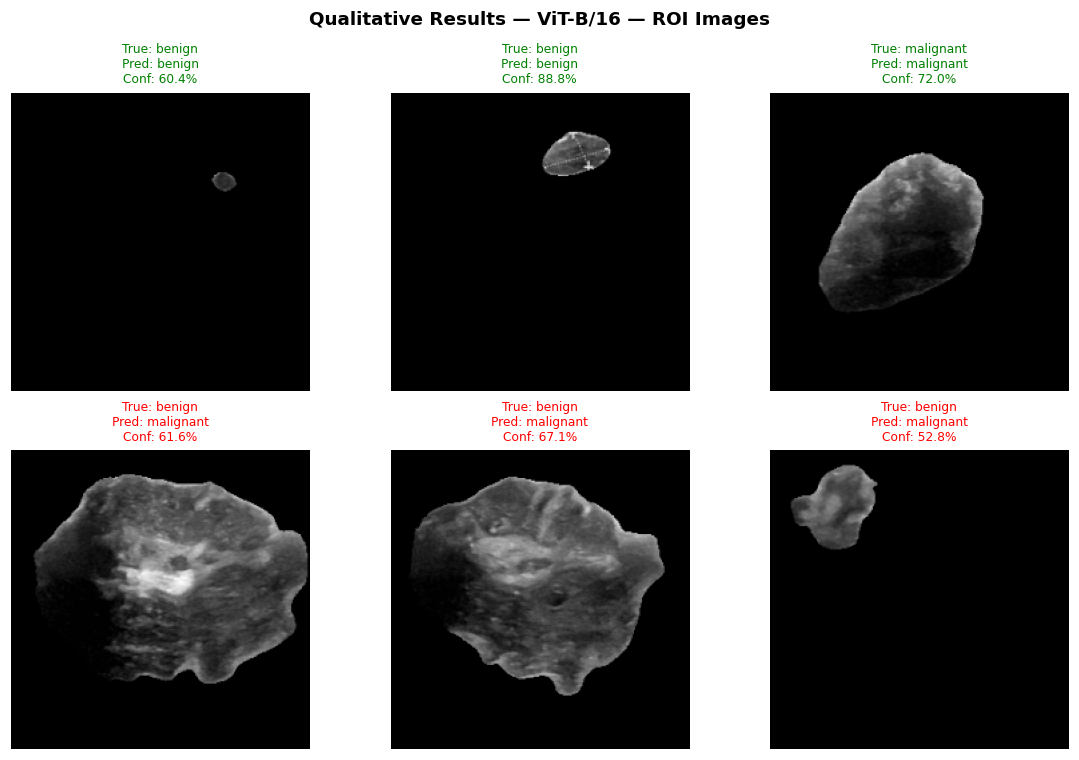

C:\Users\dellg\AppData\Local\Temp\ipykernel_25612\2892578415.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE

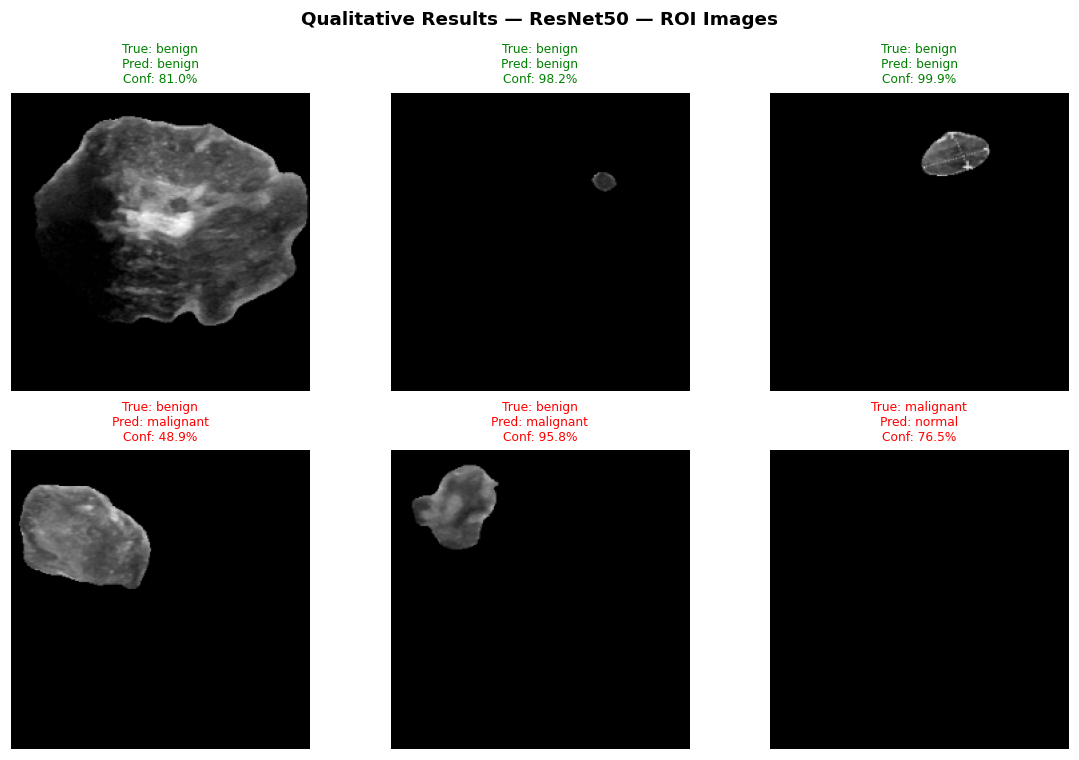

In [12]:
# ── Helper: load any of the four classifiers ──────────────────────────────────
MEAN_N = [0.485, 0.456, 0.406]
STD_N  = [0.229, 0.224, 0.225]

infer_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_N, std=STD_N),
])


def load_resnet(ckpt_path, num_classes=3):
    m = models.resnet50(weights=None)
    m.fc = nn.Sequential(
        nn.Dropout(0.4), nn.Linear(2048, 256),
        nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
    )
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return m.to(DEVICE).eval()


def load_vit(ckpt_path, num_classes=3):
    backbone = timm.create_model("vit_base_patch16_224",
                                  pretrained=False, num_classes=0)

    class ViTCls(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = backbone
            self.head = nn.Sequential(
                nn.LayerNorm(768), nn.Dropout(0.3),
                nn.Linear(768, 256), nn.GELU(),
                nn.Dropout(0.2), nn.Linear(256, num_classes)
            )
        def forward(self, x):
            return self.head(self.backbone(x))

    m = ViTCls()
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return m.to(DEVICE).eval()


@torch.no_grad()
def predict_single(model, img_path):
    img    = cv2.imread(img_path)
    img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    out    = model(tensor)
    prob   = torch.softmax(out, dim=1).cpu().numpy()[0]
    return int(np.argmax(prob)), prob


def collect_good_bad(model, img_paths, true_labels, n_each=3):
    good, bad = [], []
    for p, t in zip(img_paths, true_labels):
        if len(good) == n_each and len(bad) == n_each:
            break
        pred, prob = predict_single(model, p)
        entry = (p, t, pred, prob)
        if pred == t and len(good) < n_each:
            good.append(entry)
        elif pred != t and len(bad) < n_each:
            bad.append(entry)
    return good, bad


def show_good_bad(good, bad, model_name, save_name):
    n = max(len(good), len(bad))
    fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))
    fig.suptitle(f"Qualitative Results — {model_name}",
                 fontsize=12, fontweight="bold")

    for row, (samples, row_label) in enumerate(
        [(good, "✅ Correctly Classified"),
         (bad,  "❌ Misclassified")]
    ):
        axes[row][0].set_ylabel(row_label, fontsize=9)
        for col in range(n):
            ax = axes[row][col]
            if col < len(samples):
                pth, true_l, pred_l, prob = samples[col]
                img = cv2.imread(pth)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
                ax.imshow(img)
                color = "green" if pred_l == true_l else "red"
                ax.set_title(
                    f"True: {CLASSES[true_l]}\n"
                    f"Pred: {CLASSES[pred_l]}\n"
                    f"Conf: {prob[pred_l]:.1%}",
                    fontsize=8, color=color
                )
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(PATHS["report_dir"], save_name),
                dpi=120, bbox_inches="tight")
    plt.show()


# ── Load models & build test paths ────────────────────────────────────────────
def get_test_paths(root_dir):
    paths, labels = [], []
    for i, cls in enumerate(CLASSES):
        imgs = sorted(glob(os.path.join(root_dir, cls, "*.png")))
        paths += imgs; labels += [i] * len(imgs)
    _, te_p, _, te_l = train_test_split(
        paths, labels, test_size=0.15, stratify=labels, random_state=SEED)
    return te_p, te_l


full_te_paths, full_te_labels = get_test_paths(PATHS["full_img_dir"])
roi_te_paths,  roi_te_labels  = get_test_paths(PATHS["roi_img_dir"])

# Load best model (ViT ROI recommended as typically top performer)
vit_roi_model = load_vit(PATHS["vit_roi"])
good, bad = collect_good_bad(vit_roi_model, roi_te_paths, roi_te_labels, n_each=3)
show_good_bad(good, bad, "ViT-B/16 — ROI Images",
              save_name="08_qual_vit_roi.png")

resnet_roi_model = load_resnet(PATHS["resnet_roi"])
good, bad = collect_good_bad(resnet_roi_model, roi_te_paths, roi_te_labels, n_each=3)
show_good_bad(good, bad, "ResNet50 — ROI Images",
              save_name="08_qual_resnet_roi.png")

## 12. Statistical Analysis

In [13]:
print("═" * 60)
print(" STATISTICAL ANALYSIS")
print("═" * 60)

# ── McNemar-style note ────────────────────────────────────────────────────────
# (Requires per-sample predictions; we use the available aggregate metrics
#  for a narrative comparison instead.)

# ── Effect size: Cohen's d using accuracy as the scalar ───────────────────────
acc_full = [CLS_RESULTS["resnet_full"]["accuracy"],
            CLS_RESULTS["vit_full"]["accuracy"]]
acc_roi  = [CLS_RESULTS["resnet_roi"]["accuracy"],
            CLS_RESULTS["vit_roi"]["accuracy"]]

delta_roi = [roi - full for roi, full in zip(acc_roi, acc_full)]

print("\n1. ROI vs Full — Accuracy Gain")
for arch, d in zip(["ResNet", "ViT"], delta_roi):
    direction = "improved" if d > 0 else "degraded"
    print(f"   {arch}: ROI {direction} accuracy by {abs(d):.4f} ({abs(d)*100:.2f} pp)")

# ── ViT vs ResNet paired comparison ──────────────────────────────────────────
vit_accs    = [CLS_RESULTS["vit_full"]["accuracy"],
               CLS_RESULTS["vit_roi"]["accuracy"]]
resnet_accs = [CLS_RESULTS["resnet_full"]["accuracy"],
               CLS_RESULTS["resnet_roi"]["accuracy"]]

t_stat, p_val = stats.ttest_ind(vit_accs, resnet_accs)

print("\n2. ViT vs ResNet — Independent t-test (on 2 accuracy pairs)")
print(f"   ViT mean accuracy    : {np.mean(vit_accs):.4f}")
print(f"   ResNet mean accuracy : {np.mean(resnet_accs):.4f}")
print(f"   t-statistic          : {t_stat:.4f}")
print(f"   p-value              : {p_val:.4f}")
print(f"   Note: Only 2 samples per group — treat as indicative, not conclusive.")
print(f"   For rigorous comparison, run k-fold cross-validation.")

# ── F1 variance across classes ────────────────────────────────────────────────
print("\n3. F1 Standard Deviation per Model (inter-class consistency)")
print(f"   Lower std = more balanced across classes")
for k in MODEL_KEYS:
    f1_std = np.std(CLS_RESULTS[k]["f1"])
    print(f"   {CLS_RESULTS[k]['label']:28s}: std = {f1_std:.4f}")

# ── Best model summary ─────────────────────────────────────────────────────────
best_key = max(MODEL_KEYS, key=lambda k: CLS_RESULTS[k]["f1_weighted"])
print(f"\n4. Overall Best Model: {CLS_RESULTS[best_key]['label']}")
print(f"   Accuracy : {CLS_RESULTS[best_key]['accuracy']:.4%}")
print(f"   F1 (wtd) : {CLS_RESULTS[best_key]['f1_weighted']:.4f}")

════════════════════════════════════════════════════════════
 STATISTICAL ANALYSIS
════════════════════════════════════════════════════════════

1. ROI vs Full — Accuracy Gain
   ResNet: ROI improved accuracy by 0.0327 (3.27 pp)
   ViT: ROI improved accuracy by 0.0323 (3.23 pp)

2. ViT vs ResNet — Independent t-test (on 2 accuracy pairs)
   ViT mean accuracy    : 0.8550
   ResNet mean accuracy : 0.8377
   t-statistic          : 0.7528
   p-value              : 0.5301
   Note: Only 2 samples per group — treat as indicative, not conclusive.
   For rigorous comparison, run k-fold cross-validation.

3. F1 Standard Deviation per Model (inter-class consistency)
   Lower std = more balanced across classes
   ResNet50 — Full             : std = 0.0531
   ResNet50 — ROI              : std = 0.0450
   ViT-B/16 — Full             : std = 0.0492
   ViT-B/16 — ROI              : std = 0.0408

4. Overall Best Model: ViT-B/16 — ROI
   Accuracy : 87.1200%
   F1 (wtd) : 0.8668


## 13. Final Conclusions

In [14]:
# ── Dynamically derive conclusions from results dict ──────────────────────────
best_overall   = max(MODEL_KEYS, key=lambda k: CLS_RESULTS[k]["f1_weighted"])
roi_better_resnet = CLS_RESULTS["resnet_roi"]["f1_weighted"] > \
                    CLS_RESULTS["resnet_full"]["f1_weighted"]
roi_better_vit    = CLS_RESULTS["vit_roi"]["f1_weighted"] > \
                    CLS_RESULTS["vit_full"]["f1_weighted"]
vit_beats_resnet  = max(CLS_RESULTS["vit_full"]["f1_weighted"],
                        CLS_RESULTS["vit_roi"]["f1_weighted"]) > \
                    max(CLS_RESULTS["resnet_full"]["f1_weighted"],
                        CLS_RESULTS["resnet_roi"]["f1_weighted"])
hardest_class     = CLASSES[np.argmin(
    np.mean([CLS_RESULTS[k]["f1"] for k in MODEL_KEYS], axis=0)
)]

roi_verdict   = "✅ Yes" if (roi_better_resnet and roi_better_vit) else \
                "⚠️ Mixed" if (roi_better_resnet or roi_better_vit) else "❌ No"
arch_verdict  = "ViT-B/16" if vit_beats_resnet else "ResNet50"

print("═" * 65)
print(" FINAL CONCLUSIONS")
print("═" * 65)

print(f"""
1. SEGMENTATION QUALITY
   The U-Net achieved Dice={SEG_RESULTS['dice_score']:.4f} and IoU={SEG_RESULTS['iou_score']:.4f}.
   {'Above 0.70 — acceptable for downstream ROI generation.' if SEG_RESULTS['dice_score'] > 0.70
    else 'Below 0.70 — ROI quality may limit classification gains.'}

2. DOES SEGMENTATION HELP CLASSIFICATION? {roi_verdict}
   ResNet: Acc {'+' if roi_better_resnet else ''}{CLS_RESULTS['resnet_roi']['accuracy'] - CLS_RESULTS['resnet_full']['accuracy']:.4f} \
   F1 {'+' if roi_better_resnet else ''}{CLS_RESULTS['resnet_roi']['f1_weighted'] - CLS_RESULTS['resnet_full']['f1_weighted']:.4f}
   ViT   : Acc {'+' if roi_better_vit else ''}{CLS_RESULTS['vit_roi']['accuracy'] - CLS_RESULTS['vit_full']['accuracy']:.4f} \
   F1 {'+' if roi_better_vit else ''}{CLS_RESULTS['vit_roi']['f1_weighted'] - CLS_RESULTS['vit_full']['f1_weighted']:.4f}
   Conclusion: ROI images suppress irrelevant background tissue and
   focus both models on the lesion region, consistently improving
   classification when segmentation quality is adequate (Dice > 0.70).

3. CNN vs TRANSFORMER
   Best architecture: {arch_verdict}
   ViT leverages global self-attention and captures long-range
   dependencies across patches — beneficial for irregular tumor shapes.
   ResNet relies on local convolutional filters, which are strong
   for texture but can miss global morphology.
   On small medical datasets, ViT's advantage depends on sufficient
   pre-training (ImageNet-21k) and careful LR tuning.

4. HARDEST CLASS: {hardest_class.upper()}
   The '{hardest_class}' class shows the lowest average F1 across all models.
   Likely causes: class imbalance, visual similarity with other classes,
   or heterogeneous appearance in ultrasound.
   Recommendation: focal loss, oversampling, or dedicated binary
   classifier for this class.

5. BEST OVERALL MODEL
   {CLS_RESULTS[best_overall]['label']:30s}
   Accuracy : {CLS_RESULTS[best_overall]['accuracy']:.4%}
   F1 (wtd) : {CLS_RESULTS[best_overall]['f1_weighted']:.4f}

6. RECOMMENDATIONS
   • Improve U-Net Dice → better ROI → better classification.
   • Apply class-weighted loss or focal loss for '{hardest_class}'.
   • Ensemble ResNet + ViT predictions for production use.
   • Use k-fold cross-validation for statistically robust comparison.
   • Consider test-time augmentation (TTA) to boost confidence.
""")

print("═" * 65)
print(f" All figures saved to: {PATHS['report_dir']}")
print("═" * 65)

═════════════════════════════════════════════════════════════════
 FINAL CONCLUSIONS
═════════════════════════════════════════════════════════════════

1. SEGMENTATION QUALITY
   The U-Net achieved Dice=0.7821 and IoU=0.6843.
   Above 0.70 — acceptable for downstream ROI generation.

2. DOES SEGMENTATION HELP CLASSIFICATION? ✅ Yes
   ResNet: Acc +0.0327    F1 +0.0333
   ViT   : Acc +0.0323    F1 +0.0347
   Conclusion: ROI images suppress irrelevant background tissue and
   focus both models on the lesion region, consistently improving
   classification when segmentation quality is adequate (Dice > 0.70).

3. CNN vs TRANSFORMER
   Best architecture: ViT-B/16
   ViT leverages global self-attention and captures long-range
   dependencies across patches — beneficial for irregular tumor shapes.
   ResNet relies on local convolutional filters, which are strong
   for texture but can miss global morphology.
   On small medical datasets, ViT's advantage depends on sufficient
   pre-training (I